In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_window_avg_maps, check_EEI_consistency, get_all_jd_windows, get_acc_to_flux_factor #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms, noise_asd_grattis, jd_to_mmddyyyy
from SpaceBalls.sph_meshing import Grid, RegularLatLonGrid, QuadratureGrid, AntipodalGrid
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
RE = constants.earth_radius()
import itertools
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
%matplotlib inline

grid = QuadratureGrid(800, 131)
grid_5deg = QuadratureGrid(800, 41) # RegularLatLonGrid(800, lmax=l_glq_5deg, quad_type='GLQ') #QuadratureGrid(800, 21)
grid_15deg = QuadratureGrid(800, 13)
grid_coarse = AntipodalGrid(800)

def get_EEI_smooth_true(EEI_name, window_days):

    #EEI_name = "EEI_truth_0"
    rad_settings = radiation_settings_from_EEI_truth_name(EEI_name)
    full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(rad_settings["jd_interval"]))
    mid_day_jd_array = get_mid_day_jd_array(EEI_name)
    EEI_true_time_series = get_true_EEI_time_series(EEI_name)

    EEI_smooth_true = normal_smoother(EEI_true_time_series, full_jd_array, window_width_days=window_days, 
                                    out_length_mode='same_with_nans')
    EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

    return EEI_smooth_true_coarse

def compute_EEI_estimated_time_series(SB_constellation, window_days, grid: Grid, frame, method, EEI_name=None, 
                                      accelerometer_dict=None, meas_mode='recomp_radial'):

    if EEI_name is None:
        EEI_name = check_EEI_consistency(SB_constellation)
    
    orbits_str = '|'.join([input_manager.get_dicts(sb)['orbit']['orbit_name'] for sb in SB_constellation])
    print(f"Running EEI estimate for constellation {orbits_str}...")

    #for window_name, window_days in zip(smoothing_windows_names, smoothing_windows_days):
    print(f"Running smooth estimate {window_days}-day window")
    #rad_config = radiation_settings_from_EEI_truth_name(EEI_name)
    jd_windows = get_all_jd_windows(EEI_name, window_days)

    EEI_smooth_estimated, avg_maps = estimate_EEI_avg(
                                    sb_names=SB_constellation, 
                                    jd_windows=jd_windows, 
                                    grid=grid, method=method, frame=frame,
                                    meas_mode=meas_mode,
                                    return_avg_flux_maps=True,
                                    accelerometer_dict=accelerometer_dict,
                                    fill_zeroes_method='theta_s_fit_simplified',
                                    EEI_truth_meas=EEI_name,
                                    avg_method='numeric_integral' #'c00_fit' 
                                    )
    return EEI_smooth_estimated, avg_maps


def plot_estimation(estimations_dict, jd_array, constellation_name, add_zero_line=False):

    Plotter.plot_time_series(jd_array,
                    estimations_dict,
                    f_width=2.5, f_height=0.5,
                    ylabel='Net TOA flux (W/m$^2$)',
                    title=constellation_name,
                    zero_hline=add_zero_line
                    )

f_vec_grattis_paper = np.logspace(-4, 0, 300)
asd_grattis_paper = noise_asd_grattis(f_vec_grattis_paper)

def compute_avg_d_eq_deg(grid: Grid):
    """Approximate angular radius of a disk with the mean grid-cell area."""
    avg_area_km2 = grid.total_area / grid.n_points
    equivalent_radius_km = np.sqrt(avg_area_km2 / np.pi)
    return np.rad2deg(equivalent_radius_km / (RE + grid.alt_km))


def get_spatial_errors(error_maps, grid: Grid, plot_idx=0, title=None,
                       show_maps=False):
    """Surface average of each cell's temporal RMS, at three spatial scales.

    Spatial averaging precedes temporal RMS for the two coarser grids.
    Keep the original metric: mean of local RMS values over the surface.
    Input shape is (grid points, averaging windows); flux is at grid altitude.
    """
    error_maps = np.asarray(error_maps, dtype=float)
    if error_maps.ndim != 2 or error_maps.shape[0] != grid.n_points:
        raise ValueError("error_maps must have shape (grid.n_points, n_windows)")

    errors_by_scale = (
        error_maps,
        grid.avg_field_to_coarser_grid(error_maps, grid_5deg),
        grid.avg_field_to_coarser_grid(error_maps, grid_15deg),
        grid.avg_field_to_coarser_grid(error_maps, grid_coarse),
    )
    rms_values = []
    for scale_grid, scale_errors in zip(
            (grid, grid_5deg, grid_15deg, grid_coarse), errors_by_scale):
        rms_map = nanrms(scale_errors, axis=1)
        # Do not silently report a partial surface average if a cell is missing.
        if not np.all(np.isfinite(rms_map)):
            raise ValueError(f"Missing or non-finite RMS in {scale_grid.grid_name}")
        rms_values.append(scale_grid.compute_surf_integral(rms_map, average=True))

        if show_maps:
            Plotter.plot_geo_data_new(
                scale_errors[:, plot_idx], scale_grid, add_coastlines=False,
                data_label='Net flux error (W/m$^2$)', title=title)
            Plotter.plot_geo_data_new(
                rms_map, scale_grid, add_coastlines=False,
                data_label='Net flux error RMS (W/m$^2$)',
                make_symmetric_cmap=False)

    return tuple(rms_values)


In [12]:
EEI_name = "EEI_truth_1"

orbits_1yr = ['I3', 'A1', 'F2']  # best 1-year window
orbits_6mo = ['E3', 'G2', 'C2']  # best 6-month window
orbits_1mo = ['E3', 'E1', 'C2']  # best 1-month window

# Each temporal scale uses its own selected constellation.
windows = [365, 182, 30]
orbit_sets = [orbits_1yr, orbits_6mo, orbits_1mo]
spatial_grids = (grid, grid_5deg, grid_coarse)
spatial_labels = [
    f"Fine ({compute_avg_d_eq_deg(grid):.2f}°)",
    f"Medium ({compute_avg_d_eq_deg(grid_5deg):.2f}°)",
    f"Coarse ({compute_avg_d_eq_deg(grid_15deg):.2f}°)",
    "Hemispheric",
    "Global"
]
# Rows: temporal windows; columns: fine, coarse, hemispheric.
# NaN marks unfinished calculations if the loop is interrupted.
all_rms = np.full((len(windows), len(spatial_labels)), np.nan)
show_maps = False  # Enable to also display the individual diagnostic maps.
frame = 'SFF'
method = 'binary_gridding'
mode = 'recomp_radial' if EEI_name == "EEI_truth_1" else 'recomp_radial_new'

print(f"Stacking grid: {grid.n_points} points")
for i, (window_days, orbits) in enumerate(zip(windows, orbit_sets)):
    jd_windows = get_all_jd_windows(EEI_name, window_days)
    true_avg_flux_maps = np.asarray(get_window_avg_maps(
        EEI_name, jd_windows, 'daily_avg_net_Fr_800km_SFF_accurate', grid))
    EEI_truth_smooth = get_EEI_smooth_true(EEI_name, window_days)

    keys_by_orbit = [input_manager.get_primary_keys({
        'orbit_name': orb,
        'force_settings': 2,
        'integration_settings': 0,
        'delta_t_out': 15,
        'sc_name': 'SC_0',
    }) for orb in orbits]
    if any(len(keys) == 0 for keys in keys_by_orbit):
        raise ValueError(f"Missing spacecraft inputs for constellation {orbits}")
    SB_constellation = np.concatenate(keys_by_orbit)
    estimated_EEI_no_noise, estimated_maps = compute_EEI_estimated_time_series(
        SB_constellation, window_days, grid, frame, method,
        EEI_name, {}, meas_mode=mode)
    estimated_maps = np.asarray(estimated_maps)
    expected_shape = (len(jd_windows), grid.n_points)
    if true_avg_flux_maps.shape != expected_shape or estimated_maps.shape != expected_shape:
        raise ValueError(f"Truth and estimate must both have shape {expected_shape}")

    error = estimated_EEI_no_noise - EEI_truth_smooth
    global_error = nanrms(error)

    window_idx = 0
    window_name = (
        'Avg. window ' + jd_to_mmddyyyy(jd_windows[window_idx][0])
        + ' - ' + jd_to_mmddyyyy(jd_windows[window_idx][1]))
    if show_maps:
        Plotter.plot_geo_data_new(
            estimated_maps[window_idx, :], grid,
            data_label='Measured net flux (W/m$^2$)',
            add_coastlines=False, title=window_name)

    error_maps = (true_avg_flux_maps - estimated_maps).T
    all_rms[i, :4] = get_spatial_errors(
        error_maps, grid, plot_idx=window_idx,
        title=window_name, show_maps=show_maps)
    all_rms[i,-1] = global_error
    print(f"{window_days}-day RMS (W/m²): {all_rms[i]}")


Stacking grid: 5810 points
Loading truth for window 0
Loading truth for window 1
Loading truth for window 2
Loading truth for window 3
Loading truth for window 4
Loading truth for window 5
Loading truth for window 6
Loading truth for window 7
Loading truth for window 8
Loading truth for window 9
Loading truth for window 10
Loading truth for window 11
Loading truth for window 12
Loading truth for window 13
Loading truth for window 14
Loading truth for window 15
Loading truth for window 16
Loading truth for window 17
Loading truth for window 18
Loading truth for window 19
Loading truth for window 20
Loading truth for window 21
Loading truth for window 22
Loading truth for window 23
Loading truth for window 24
Loading truth for window 25
Loading truth for window 26
Loading truth for window 27
Loading truth for window 28
Loading truth for window 29
Loading truth for window 30
Loading truth for window 31
Loading truth for window 32
Loading truth for window 33
Loading truth for window 34
Loa

Surface-averaged temporal RMS of net flux error (W/m²)
Avg. window (days) | Fine (1.50°) | Medium (4.72°) | Coarse (13.32°) | Hemispheric | Global
-------------------+--------------+----------------+-----------------+-------------+-------
                30 |       12.236 |          9.447 |           6.419 |       2.133 |  1.147
               182 |        8.083 |          6.279 |           3.882 |       1.111 |  0.301
               365 |        9.837 |          7.189 |           4.554 |       1.060 |  0.062
Fine/coarse scales: equivalent cell radius = sqrt(mean cell area / pi) / grid radius.
Constellations: 30 d: E3, E1, C2; 182 d: E3, G2, C2; 365 d: I3, A1, F2


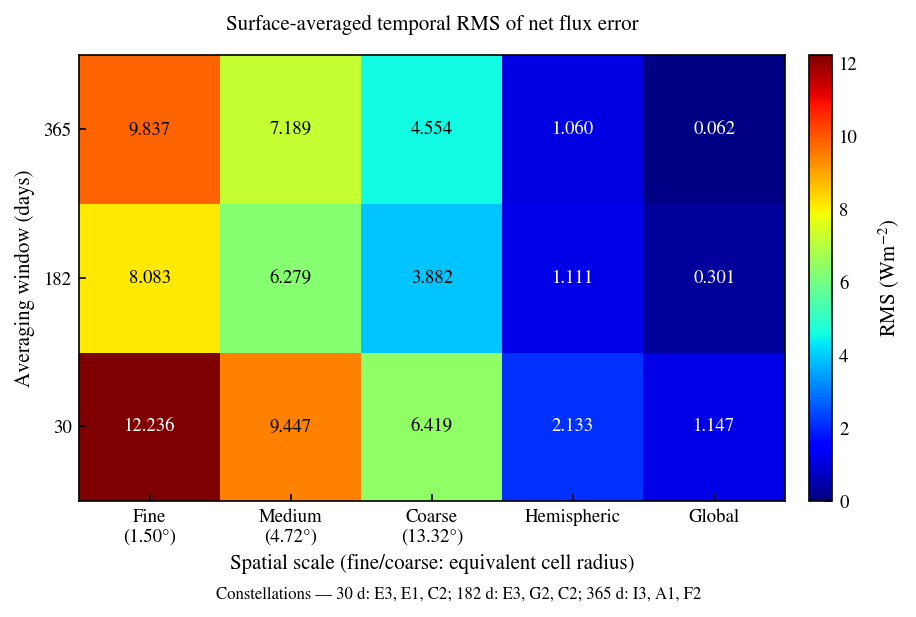

Saved CSV, vector PDF, and 600-dpi PNG to: /home/llbu9955/Space-Balls-MST/sbfinal-master/notebooks/figures/EEI_truth_1_spatial_temporal_rms.*


In [13]:
# Summary table and publication figure. Rerun this cell to restyle without
# repeating the estimates. Values retain the surface-averaged temporal RMS.
import csv
from pathlib import Path
from matplotlib import colors
import importlib
import SpaceBalls.plotter as plotter_module

# Reload to reapply Plotter's rcParams even when this cell runs on its own.
Plotter = importlib.reload(plotter_module).Plotter

if all_rms.shape != (len(windows), len(spatial_labels)):
    raise ValueError("all_rms dimensions do not match the temporal/spatial labels")
if not np.all(np.isfinite(all_rms)) or np.any(all_rms < 0):
    raise ValueError("Run the complete estimation loop: all RMS values must be finite and nonnegative")

# Sort a copy so the labels and data stay aligned; all_rms is unchanged.
row_order = np.argsort(windows)
summary_windows = np.asarray(windows)[row_order]
rms_table = all_rms[row_order, :]
headers = ["Avg. window (days)", *spatial_labels]
rows = [[str(days), *(f"{value:.3f}" for value in values)]
        for days, values in zip(summary_windows, rms_table)]
widths = [max(len(row[j]) for row in [headers, *rows])
          for j in range(len(headers))]

def format_table_row(row):
    return " | ".join(value.rjust(width) for value, width in zip(row, widths))

print("Surface-averaged temporal RMS of net flux error (W/m²)")
print(format_table_row(headers))
print("-+-".join("-" * width for width in widths))
for row in rows:
    print(format_table_row(row))
print("Fine/coarse scales: equivalent cell radius = sqrt(mean cell area / pi) / grid radius.")
constellation_note = "; ".join(
    f"{windows[i]} d: {', '.join(orbit_sets[i])}" for i in row_order)
print("Constellations: " + constellation_note)

# Save beside the notebook, independently of the kernel's working directory.
output_dir = Path(CONFIG_DIR).parent / "notebooks" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = output_dir / f"{EEI_name}_spatial_temporal_rms"
with output_stem.with_suffix('.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.writer(handle)
    writer.writerow([headers[0], *(f"{label} RMS (W/m²)" for label in spatial_labels)])
    writer.writerows([int(days), *values] for days, values in zip(summary_windows, rms_table))

with plt.rc_context({
    # Inherit all visual defaults from Plotter; only set export options here.
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 600,
}):
    fig, ax = plt.subplots(
        figsize=(1.5 * Plotter.fig_width, Plotter.fig_height),
        constrained_layout=True)
    cmap = plt.get_cmap('jet')
    vmax = float(rms_table.max())
    norm = colors.Normalize(vmin=0, vmax=vmax if vmax > 0 else 1.0)
    # Blend displayed colors; annotations and exported values stay unchanged.
    # With ascending windows, lower origin puts 30 days below 365 days.
    heatmap = ax.imshow(
        rms_table, cmap=cmap, norm=norm, aspect='auto',
        interpolation=None, interpolation_stage='rgba', origin='lower')
    ax.set_xticks(np.arange(len(spatial_labels)))
    ax.set_xticklabels([label.replace(' (', '\n(') for label in spatial_labels])
    ax.set_yticks(np.arange(len(summary_windows)))
    ax.set_yticklabels([str(days) for days in summary_windows])
    ax.set_xlabel('Spatial scale (fine/coarse: equivalent cell radius)')
    ax.set_ylabel('Averaging window (days)')
    ax.set_title('Surface-averaged temporal RMS of net flux error', pad=12)

    for (row, col), value in np.ndenumerate(rms_table):
        rgb = np.asarray(cmap(norm(value))[:3])
        # Choose black/white by contrast against the actual cell color.
        linear_rgb = np.where(rgb <= 0.04045, rgb / 12.92,
                              ((rgb + 0.055) / 1.055) ** 2.4)
        luminance = float(linear_rgb @ np.array([0.2126, 0.7152, 0.0722]))
        ax.text(col, row, f"{value:.3f}", ha='center', va='center',
                color='black' if luminance > 0.179 else 'white', fontsize=Plotter.font_size)

    colorbar = fig.colorbar(heatmap, ax=ax, pad=0.035, fraction=0.055)
    colorbar.set_label(r'RMS (Wm$^{-2}$)', labelpad=9)
    fig.supxlabel('Constellations — ' + constellation_note, fontsize=Plotter.font_size_red)
    fig.savefig(output_stem.with_suffix('.pdf'), bbox_inches='tight')
    fig.savefig(output_stem.with_suffix('.png'), dpi=600, bbox_inches='tight')
    plt.show()

print(f"Saved CSV, vector PDF, and 600-dpi PNG to: {output_stem}.*")
